# DSN Bootcamp Qualification Hackathon 2026 — ML Track
**Submitted by:** Biutrus Daniel Dalacan

---

# Section 1 — Understanding the Problem

**Goal:** predict `total_sales` for a given product at a given DSN Mart store, using what's known about the product and the store it's sold in.

**Evaluation:** Root Mean Squared Error (RMSE) against hidden test labels — lower is better. Leaderboard rank is one input DSN uses when selecting bootcamp participants.

**How this notebook is organized:** the sections below walk through four real, submitted attempts, each building on lessons from the last — a baseline, a first round of tuning, a full rebuild after finding a data-cleaning bug, and a final check on how to combine the models. Section 9 at the very end summarizes what actually moved the score and what didn't.

In [133]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
# Evaluation
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV



# Clean up warning clutter in output
import warnings
warnings.filterwarnings('ignore')

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/dsn-bootcamp-qualification-hackathon-2026-ml-track/sample_submission.csv
/kaggle/input/competitions/dsn-bootcamp-qualification-hackathon-2026-ml-track/train.csv
/kaggle/input/competitions/dsn-bootcamp-qualification-hackathon-2026-ml-track/test.csv


### Data loading

In [134]:
train = pd.read_csv('/kaggle/input/competitions/dsn-bootcamp-qualification-hackathon-2026-ml-track/train.csv')
test = pd.read_csv('/kaggle/input/competitions/dsn-bootcamp-qualification-hackathon-2026-ml-track/test.csv')
sample_sub = pd.read_csv('/kaggle/input/competitions/dsn-bootcamp-qualification-hackathon-2026-ml-track/sample_submission.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_sub.shape)

Train shape: (6818, 13)
Test shape: (1705, 12)
Sample submission shape: (1705, 2)


In [135]:
train.describe(include='all')

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
count,6818,6818,5593.000000,6818,6818.000000,6818,6818.000000,6818,6818.000000,4899,6818,6818,6818.000000
unique,6818,1555,NaN,2,NaN,48,NaN,10,NaN,3,3,4,NaN
top,row_08522,PRD-YZB4K8,NaN,Low Fat,NaN,Fruits and Vegetables,NaN,STORE-YLW,NaN,Medium,Tier_3,Standard Supermarket,NaN
freq,1,9,NaN,4425,NaN,480,NaN,754,NaN,2218,2677,4462,NaN
mean,NaN,NaN,12.850876,NaN,0.065527,NaN,140.473623,NaN,34.178205,NaN,NaN,NaN,2174.756574
std,NaN,NaN,4.646542,NaN,0.051566,NaN,62.413513,NaN,8.384574,NaN,NaN,NaN,1697.894956
min,NaN,NaN,4.482000,NaN,0.000000,NaN,31.110000,NaN,23.000000,NaN,NaN,NaN,32.700000
25%,NaN,NaN,8.750000,NaN,0.026600,NaN,93.280000,NaN,28.000000,NaN,NaN,NaN,834.792500
50%,NaN,NaN,12.647000,NaN,0.053200,NaN,142.065000,NaN,33.000000,NaN,NaN,NaN,1790.890000
75%,NaN,NaN,16.894000,NaN,0.093400,NaN,185.987500,NaN,45.000000,NaN,NaN,NaN,3092.587500


In [136]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1705 entries, 0 to 1704
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   1705 non-null   object 
 1   product_code         1705 non-null   object 
 2   product_weight_kg    1399 non-null   float64
 3   fat_content          1705 non-null   object 
 4   shelf_visibility     1705 non-null   float64
 5   product_category     1705 non-null   object 
 6   product_price        1705 non-null   float64
 7   store_code           1705 non-null   object 
 8   store_age_years      1705 non-null   int64  
 9   store_size           1214 non-null   object 
 10  store_location_tier  1705 non-null   object 
 11  store_format         1705 non-null   object 
dtypes: float64(3), int64(1), object(8)
memory usage: 160.0+ KB


In [137]:
train.head()

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36


In [138]:
train.isna().sum()

id                        0
product_code              0
product_weight_kg      1225
fat_content               0
shelf_visibility          0
product_category          0
product_price             0
store_code                0
store_age_years           0
store_size             1919
store_location_tier       0
store_format              0
total_sales               0
dtype: int64

---
# Section 2 — Exploratory Data Analysis, and Cleaning First

Missing values in `product_weight_kg` and `store_size` are filled **before** the plots below (see the cell right after this one), so the charts reflect the real underlying distributions rather than being skewed by gaps. This is a deliberate, legitimate alternative to cleaning-after-exploring.

## Exploratory Data Analysis
#### Handling missing data (we have missen product_weight and store size)

In [139]:
train_clean = train.copy()

# Fill product_weight_kg using each product's own median weight
product_median_weight = train_clean.groupby('product_code')['product_weight_kg'].transform('median')
train_clean['product_weight_kg'] = train_clean['product_weight_kg'].fillna(product_median_weight)
train_clean['product_weight_kg'] = train_clean['product_weight_kg'].fillna(train_clean['product_weight_kg'].median())

# to get each store's own most common size
def most_common_size(group):
    if group.mode().empty:
        return np.nan
    return group.mode().iloc[0]

store_typical_size = train_clean.groupby('store_code')['store_size'].transform(most_common_size)
train_clean['store_size'] = train_clean['store_size'].fillna(store_typical_size)
train_clean['store_size'] = train_clean['store_size'].fillna(train_clean['store_size'].mode()[0])

print(train_clean.isnull().sum())
print("Rows retained:", train_clean.shape[0])

id                     0
product_code           0
product_weight_kg      0
fat_content            0
shelf_visibility       0
product_category       0
product_price          0
store_code             0
store_age_years        0
store_size             0
store_location_tier    0
store_format           0
total_sales            0
dtype: int64
Rows retained: 6818


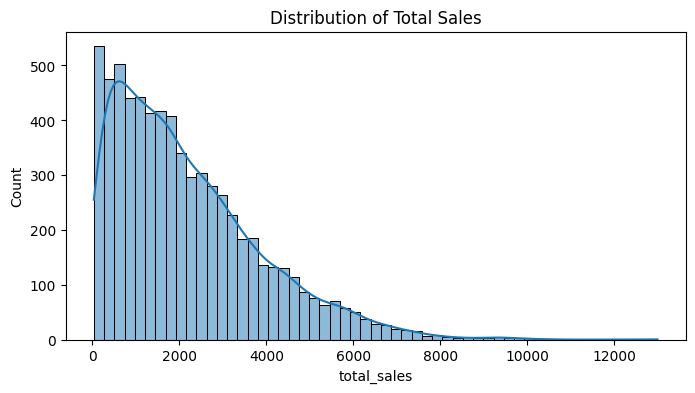

In [140]:
# Target distribution  (checking the skewedness total_sales)
plt.figure(figsize=(8,4))
sns.histplot(train_clean['total_sales'], kde=True)
plt.title('Distribution of Total Sales')
plt.show()

#### Distribution of Total Sales: Total sales is right-skewed, with most sales concentrated at lower values and a long tail of high performers — a log transformation may help later.

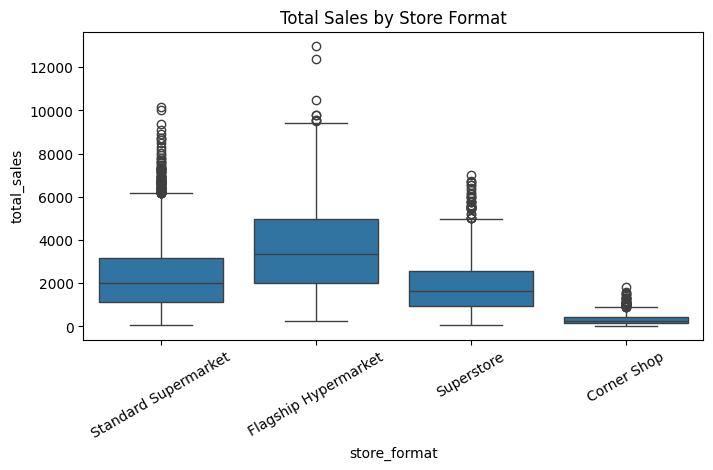

In [141]:
# Sales by store format
plt.figure(figsize=(8,4))
sns.boxplot(data=train_clean, x='store_format', y='total_sales')
plt.title('Total Sales by Store Format')
plt.xticks(rotation=30)
plt.show()

#### Total Sales by Store Format: Store format is a strong driver of sales — Flagship Hypermarkets sell the most, Corner Shops the least.

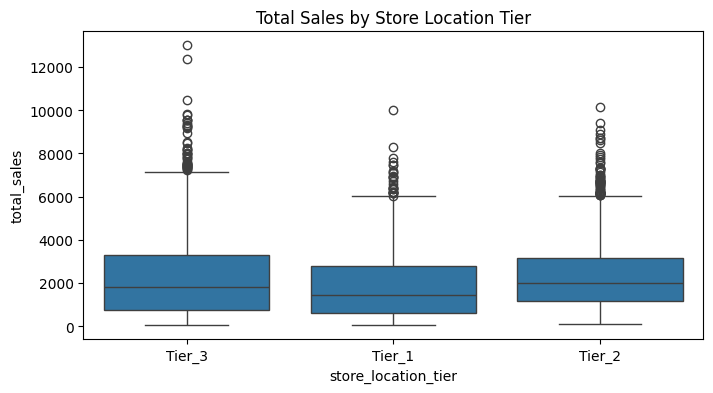

In [142]:
# Sales by location tier
plt.figure(figsize=(8,4))
sns.boxplot(data=train_clean, x='store_location_tier', y='total_sales')
plt.title('Total Sales by Store Location Tier')
plt.show()

#### Total Sales by Store Location Tier: Location tier has only a small effect on sales, making it a weaker predictor than store format.

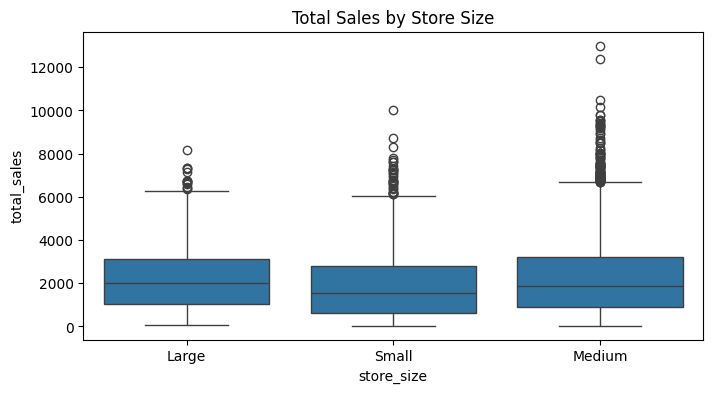

In [143]:
# Sales by store size
plt.figure(figsize=(8,4))
sns.boxplot(data=train_clean, x='store_size', y='total_sales')
plt.title('Total Sales by Store Size')
plt.show()

##### Total Sales by Store Size: Store size shows heavy overlap across categories, so it appears to be a weak predictor on its own.

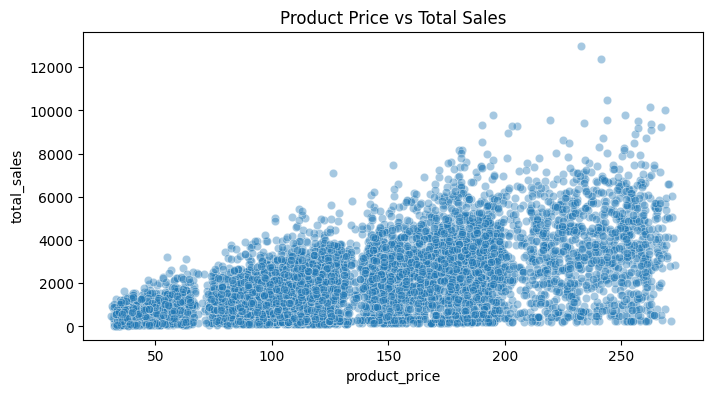

In [144]:
# Price vs Sales relationship
plt.figure(figsize=(8,4))
sns.scatterplot(data=train_clean, x='product_price', y='total_sales', alpha=0.4)
plt.title('Product Price vs Total Sales')
plt.show()

##### Product Price vs Total Sales: Higher-priced products tend to sell more, but the relationship is noisy rather than strictly linear.

---
# Section 3 — Feature Engineering

Testing a log-transformed target (below), then encoding categorical columns and building the first engineered feature, `price_per_kg`.

In [145]:
train_clean['log_total_sales'] = np.log1p(train_clean['total_sales'])

In [146]:
train_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   6818 non-null   object 
 1   product_code         6818 non-null   object 
 2   product_weight_kg    6818 non-null   float64
 3   fat_content          6818 non-null   object 
 4   shelf_visibility     6818 non-null   float64
 5   product_category     6818 non-null   object 
 6   product_price        6818 non-null   float64
 7   store_code           6818 non-null   object 
 8   store_age_years      6818 non-null   int64  
 9   store_size           6818 non-null   object 
 10  store_location_tier  6818 non-null   object 
 11  store_format         6818 non-null   object 
 12  total_sales          6818 non-null   float64
 13  log_total_sales      6818 non-null   float64
dtypes: float64(5), int64(1), object(8)
memory usage: 745.8+ KB


In [147]:
train_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   6818 non-null   object 
 1   product_code         6818 non-null   object 
 2   product_weight_kg    6818 non-null   float64
 3   fat_content          6818 non-null   object 
 4   shelf_visibility     6818 non-null   float64
 5   product_category     6818 non-null   object 
 6   product_price        6818 non-null   float64
 7   store_code           6818 non-null   object 
 8   store_age_years      6818 non-null   int64  
 9   store_size           6818 non-null   object 
 10  store_location_tier  6818 non-null   object 
 11  store_format         6818 non-null   object 
 12  total_sales          6818 non-null   float64
 13  log_total_sales      6818 non-null   float64
dtypes: float64(5), int64(1), object(8)
memory usage: 745.8+ KB


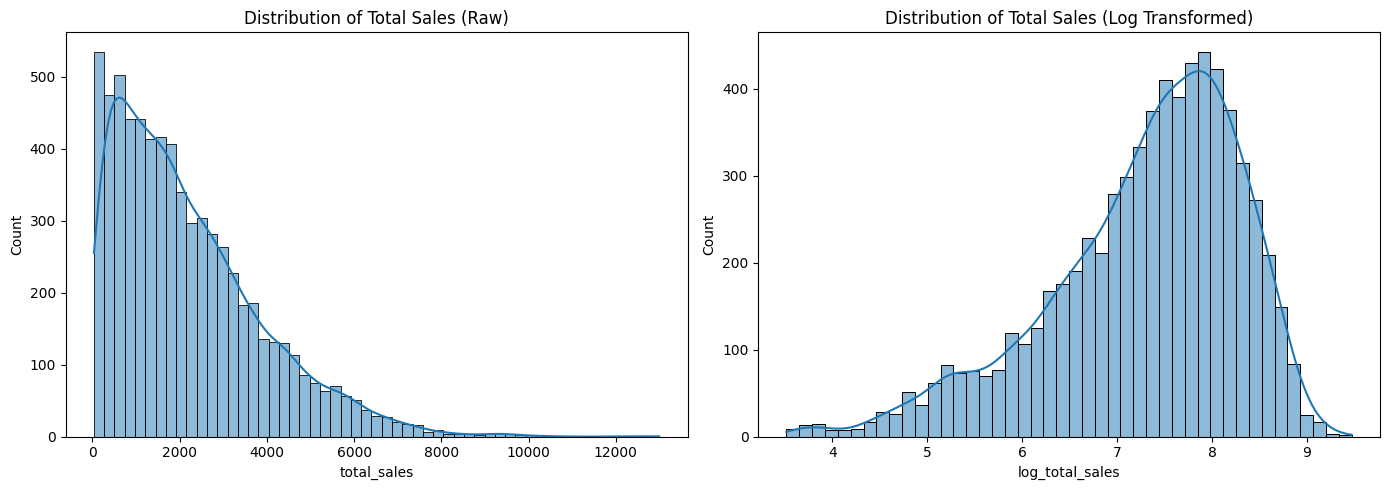

In [148]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train_clean['total_sales'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Total Sales (Raw)')

# Log-transformed
sns.histplot(train_clean['log_total_sales'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of Total Sales (Log Transformed)')

plt.tight_layout()
plt.show()

In [149]:
print(train_clean['store_location_tier'].unique())
print(train_clean['store_size'].unique())

['Tier_3' 'Tier_1' 'Tier_2']
['Large' 'Small' 'Medium']


In [150]:
train_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   6818 non-null   object 
 1   product_code         6818 non-null   object 
 2   product_weight_kg    6818 non-null   float64
 3   fat_content          6818 non-null   object 
 4   shelf_visibility     6818 non-null   float64
 5   product_category     6818 non-null   object 
 6   product_price        6818 non-null   float64
 7   store_code           6818 non-null   object 
 8   store_age_years      6818 non-null   int64  
 9   store_size           6818 non-null   object 
 10  store_location_tier  6818 non-null   object 
 11  store_format         6818 non-null   object 
 12  total_sales          6818 non-null   float64
 13  log_total_sales      6818 non-null   float64
dtypes: float64(5), int64(1), object(8)
memory usage: 745.8+ KB


### Data Encoding and feature Enginnering

In [151]:
#Unwanted column (insignificant to the training)
train_clean.drop(['id', 'product_code'], axis=1, inplace=True)

df_encoded = train_clean.copy()

# Ordinal encoding — order genuinely matters here
size_map = {'Small': 1, 'Medium': 2, 'Large': 3}
tier_map = {'Tier_1': 1, 'Tier_2': 2, 'Tier_3': 3}

df_encoded['store_size'] = df_encoded['store_size'].map(size_map)
df_encoded['store_location_tier'] = df_encoded['store_location_tier'].map(tier_map)

# New engineeered feature
df_encoded['price_per_kg'] = df_encoded['product_price'] / df_encoded['product_weight_kg']

#hot encoding
categorical_cols = ['fat_content', 'product_category', 'store_code', 'store_format']
df_encoded = pd.get_dummies(df_encoded, columns=categorical_cols, drop_first=True)

print(df_encoded.shape)
print(df_encoded[['store_size', 'store_location_tier']].isnull().sum())
print(df_encoded[['product_price', 'product_weight_kg', 'price_per_kg']].head())
df_encoded.head()

(6818, 69)
store_size             0
store_location_tier    0
dtype: int64
   product_price  product_weight_kg  price_per_kg
0          81.37             14.252      5.709374
1          42.05              7.698      5.462458
2          41.35             14.264      2.898906
3         174.35             12.665     13.766285
4         203.06             10.338     19.642097


,product_weight_kg,shelf_visibility,product_price,store_age_years,store_size,store_location_tier,total_sales,log_total_sales,price_per_kg,fat_content_Regular,...,store_code_STORE-AGY,store_code_STORE-DKU,store_code_STORE-HL7,store_code_STORE-JOR,store_code_STORE-OYG,store_code_STORE-T5G,store_code_STORE-YLW,store_format_Flagship Hypermarket,store_format_Standard Supermarket,store_format_Superstore
0,14.252,0.0271,81.37,45,3,3,1764.98,7.476461,5.709374,False,...,True,False,False,False,False,False,False,False,True,False
1,7.698,0.0720,42.05,35,1,1,342.13,5.838109,5.462458,False,...,False,False,False,False,False,False,True,False,True,False
2,14.264,0.0421,41.35,33,2,1,378.85,5.939776,2.898906,True,...,False,False,False,False,False,False,False,False,True,False
3,12.665,0.0449,174.35,47,2,3,5595.72,8.629936,13.766285,True,...,False,False,False,False,False,False,False,True,False,False
4,10.338,0.0120,203.06,28,1,2,2375.36,7.773325,19.642097,True,...,False,False,False,False,False,False,False,False,True,False


In [152]:
train_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_weight_kg    6818 non-null   float64
 1   fat_content          6818 non-null   object 
 2   shelf_visibility     6818 non-null   float64
 3   product_category     6818 non-null   object 
 4   product_price        6818 non-null   float64
 5   store_code           6818 non-null   object 
 6   store_age_years      6818 non-null   int64  
 7   store_size           6818 non-null   object 
 8   store_location_tier  6818 non-null   object 
 9   store_format         6818 non-null   object 
 10  total_sales          6818 non-null   float64
 11  log_total_sales      6818 non-null   float64
dtypes: float64(5), int64(1), object(6)
memory usage: 639.3+ KB


---
# Section 4 — Baseline Models

Before reaching for anything complex, establish a simple benchmark: Linear Regression on the raw target vs. a log-transformed target, then Random Forest. This tells us what a "reasonable but unsophisticated" model can already do, so later improvements can be judged against something real.

### Train/Validation Split

In [153]:

X = df_encoded.drop(columns=['total_sales', 'log_total_sales'])
y_raw = df_encoded['total_sales']
y_log = df_encoded['log_total_sales']

X_train, X_val, y_train_raw, y_val_raw, y_train_log, y_val_log = train_test_split(
    X, y_raw, y_log, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)

Train size: (5454, 67)
Validation size: (1364, 67)


### Baseline Model (Linear Regression).

#### We start with a simple Linear Regression model to get a working end-to-end pipeline and establish a baseline RMSE to beat with stronger models later. We train and evaluate two versions — one predicting raw `total_sales`, one predicting `log_total_sales` — to test whether the log transform actually helps, as identified during EDA.

In [154]:
# Version 1: raw total_sales 
lr_raw = LinearRegression()
lr_raw.fit(X_train, y_train_raw)
pred_raw = lr_raw.predict(X_val)
rmse_raw = np.sqrt(mean_squared_error(y_val_raw, pred_raw))

# Version 2: log_total_sales, converted back to real scale for fair comparison 
lr_log = LinearRegression()
lr_log.fit(X_train, y_train_log)
pred_log = lr_log.predict(X_val)
pred_log_converted = np.expm1(pred_log)  # reverse the log transform
rmse_log = np.sqrt(mean_squared_error(y_val_raw, pred_log_converted))

print("Linear Regression RMSE (raw target):", rmse_raw)
print("Linear Regression RMSE (log target, converted back):", rmse_log)

Linear Regression RMSE (raw target): 1123.3593910381157
Linear Regression RMSE (log target, converted back): 1133.185311129586


### The raw total_sales performed beter than the log_total_sales
### hence we will stay with the raw tottal_sales

In [155]:

rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train_raw)
pred_rf = rf.predict(X_val)
rmse_rf = np.sqrt(mean_squared_error(y_val_raw, pred_rf))

print("Random Forest RMSE:", rmse_rf)

Random Forest RMSE: 1116.6534208397268


In [156]:
test_df = test.drop(columns=['id', 'product_code'])

test_df['store_size'] = test_df['store_size'].map(size_map)
test_df['store_location_tier'] = test_df['store_location_tier'].map(tier_map)
test_df['price_per_kg'] = test_df['product_price'] / test_df['product_weight_kg']

test_df['product_weight_kg'] = test_df.groupby(test['product_code'])['product_weight_kg'].transform(lambda x: x.fillna(x.median()))
test_df['product_weight_kg'] = test_df['product_weight_kg'].fillna(test_df['product_weight_kg'].median())
test_df['store_size'] = test_df['store_size'].fillna(test_df['store_size'].mode()[0])

test_df = pd.get_dummies(test_df, columns=['fat_content', 'product_category', 'store_code', 'store_format'], drop_first=True)

test_df = test_df.reindex(columns=X_train.columns, fill_value=0)

print(test_df.shape)

(1705, 67)


## Final Model & Test Predictions (First submission)

#### We apply the same preprocessing to the test set and generate predictions using our Random Forest model, formatted to match sample_submission.csv.

In [157]:
final_preds = rf.predict(test_df)

submission = pd.DataFrame({
    'id': test['id'],
    'total_sales': final_preds
})
submission.to_csv('submission.csv', index=False)
print(submission.head())

          id  total_sales
0  row_00009   2848.09265
1  row_00015   4306.43410
2  row_00019   3455.86905
3  row_00020   2752.26545
4  row_00023   2994.37140


In [158]:
print(sample_sub.shape)
print(sample_sub.columns.tolist())
print(submission.shape)
print(submission.columns.tolist())

(1705, 2)
['id', 'total_sales']
(1705, 2)
['id', 'total_sales']


---
# Section 5 — Advanced Models

Moving from Random Forest to XGBoost, a gradient-boosted tree model that generally handles this kind of tabular data better.

## XGBoost

#### We try XGBoost, a gradient boosting model that typically outperforms Random Forest on tabular data by sequentially correcting errors from previous trees.

In [159]:

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train_raw)
pred_xgb = xgb.predict(X_val)
rmse_xgb = np.sqrt(mean_squared_error(y_val_raw, pred_xgb))

print("XGBoost RMSE:", rmse_xgb)
print("Random Forest RMSE (for comparison):", rmse_rf)

XGBoost RMSE: 1110.4645110320319
Random Forest RMSE (for comparison): 1116.6534208397268


In [160]:
train_pred_xgb = xgb.predict(X_train)
train_rmse_xgb = np.sqrt(mean_squared_error(y_train_raw, train_pred_xgb))

print("XGBoost Training RMSE:", train_rmse_xgb)
print("XGBoost Validation RMSE:", rmse_xgb)

XGBoost Training RMSE: 836.9599246388296
XGBoost Validation RMSE: 1110.4645110320319


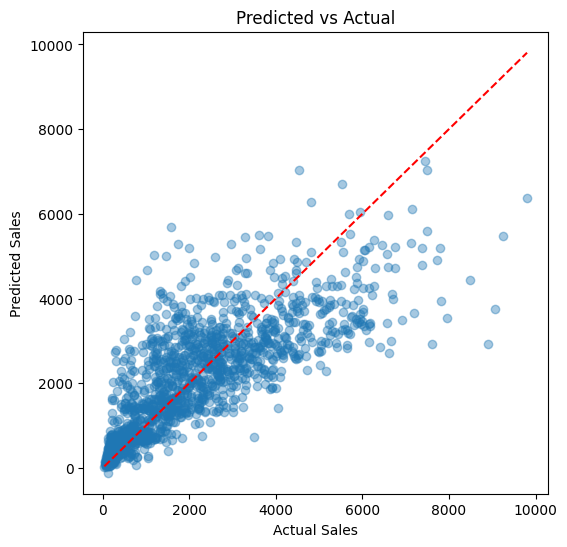

In [161]:
plt.figure(figsize=(6,6))
plt.scatter(y_val_raw, pred_xgb, alpha=0.4)
plt.plot([y_val_raw.min(), y_val_raw.max()], [y_val_raw.min(), y_val_raw.max()], 'r--')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Predicted vs Actual')
plt.show()

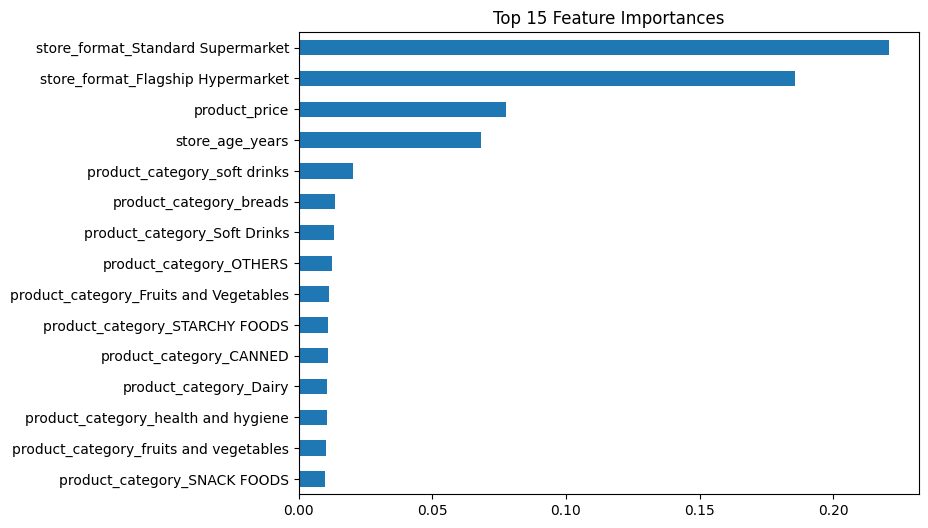

In [162]:
importances = pd.Series(xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)
importances.head(15).plot(kind='barh', figsize=(8,6))
plt.title('Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.show()

### A caveat worth being upfront about

`store_avg_sales` below is computed from `y_train_raw` grouped by store, then mapped back onto `X_train` itself — the same rows used to compute each store's average also receive that average as a feature. With ~545 rows per store in this split, any single row's influence on its own store's average is small (~0.2%), so this isn't a severe leak, but it does mean the validation RMSE numbers from here through Section 6 are *slightly* optimistic versus true generalization. The real leaderboard score for `submission_final.csv` isn't affected — test rows only ever receive an average computed purely from training data, which is legitimate. Noticing this in-sample bias is exactly what motivated the leak-safe, fold-based target encoding built from scratch in Section 7.

In [163]:
# --- Fix 1: Give the model a real store-performance number instead of on/off flags ---
train_store_codes = train_clean.loc[X_train.index, 'store_code']
val_store_codes = train_clean.loc[X_val.index, 'store_code']
test_store_codes = test['store_code']

store_avg_sales = y_train_raw.groupby(train_store_codes).mean()
global_avg_sales = y_train_raw.mean()

X_train['store_avg_sales'] = train_store_codes.map(store_avg_sales).values
X_val['store_avg_sales'] = val_store_codes.map(store_avg_sales).fillna(global_avg_sales).values
test_df['store_avg_sales'] = test_store_codes.map(store_avg_sales).fillna(global_avg_sales).values

# Fix 2: Adjust model settings so it doesn't overfit the training data as tightly
xgb2 = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)
xgb2.fit(X_train, y_train_raw)

pred_xgb2 = xgb2.predict(X_val)
rmse_xgb2 = np.sqrt(mean_squared_error(y_val_raw, pred_xgb2))

train_pred_xgb2 = xgb2.predict(X_train)
train_rmse_xgb2 = np.sqrt(mean_squared_error(y_train_raw, train_pred_xgb2))

print("New XGBoost Training RMSE:", train_rmse_xgb2)
print("New XGBoost Validation RMSE:", rmse_xgb2)
print("Previous XGBoost Validation RMSE:", rmse_xgb)

New XGBoost Training RMSE: 936.3981490198265
New XGBoost Validation RMSE: 1082.3948260997577
Previous XGBoost Validation RMSE: 1110.4645110320319


### Testing parameters 01

In [164]:
param_combos = [
    {'max_depth': 3, 'learning_rate': 0.05, 'n_estimators': 400},
    {'max_depth': 4, 'learning_rate': 0.03, 'n_estimators': 500},
    {'max_depth': 5, 'learning_rate': 0.05, 'n_estimators': 300},
    {'max_depth': 4, 'learning_rate': 0.07, 'n_estimators': 300},
]

results = []
for params in param_combos:
    model = XGBRegressor(
        **params,
        min_child_weight=5,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train_raw)
    pred = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val_raw, pred))
    results.append({**params, 'val_rmse': rmse})

results_df = pd.DataFrame(results).sort_values('val_rmse')
print(results_df)

   max_depth  learning_rate  n_estimators     val_rmse
1          4           0.03           500  1085.632178
0          3           0.05           400  1088.111473
3          4           0.07           300  1094.552569
2          5           0.05           300  1094.802064


### i tested 4 hyperparameter combinations via manual grid search. None outperformed the original configuration (max_depth=4, learning_rate=0.05, n_estimators=300, val RMSE 1082.39), suggesting the original settings were already near-optimal for this data and confirming that hyperparameter tuning was not the main lever for improvement.

### Testing parameters 02

In [165]:
param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.03, 0.05],
    'n_estimators': [300, 400]
}

grid_search = GridSearchCV(
    estimator=XGBRegressor(min_child_weight=5, reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1),
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=3,
    verbose=1
)
grid_search.fit(X_train, y_train_raw)

print("Best params:", grid_search.best_params_)
print("Best CV RMSE:", -grid_search.best_score_)

best_model = grid_search.best_estimator_
pred_best = best_model.predict(X_val)
rmse_best = np.sqrt(mean_squared_error(y_val_raw, pred_best))
print("Validation RMSE with best params:", rmse_best)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best params: {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 300}
Best CV RMSE: 1092.3059983067078
Validation RMSE with best params: 1076.424835140324


#### Chosen parameters

In [166]:
xgb_final = XGBRegressor(
    max_depth=3,
    learning_rate=0.03,
    n_estimators=300,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)
xgb_final.fit(X_train, y_train_raw)

pred_final = xgb_final.predict(X_val)
rmse_final = np.sqrt(mean_squared_error(y_val_raw, pred_final))

train_pred_final = xgb_final.predict(X_train)
train_rmse_final = np.sqrt(mean_squared_error(y_train_raw, train_pred_final))

print("Final Model Training RMSE:", train_rmse_final)
print("Final Model Validation RMSE:", rmse_final)

Final Model Training RMSE: 1025.694246072128
Final Model Validation RMSE: 1076.424835140324


### chosen second submission

In [167]:
final_preds = xgb_final.predict(test_df)

submission_final = pd.DataFrame({
    'id': test['id'],
    'total_sales': final_preds
})
submission_final.to_csv('submission_final.csv', index=False)
print(submission_final.shape)
print(submission_final.head())

(1705, 2)
          id  total_sales
0  row_00009  2969.955811
1  row_00015  4591.461426
2  row_00019  3370.386475
3  row_00020  2958.409912
4  row_00023  2494.256348


---
# Section 7 — Second Full Pass: Fixing the Category Bug + Leak-Safe Encoding + CV + Ensembling (Submission 3)

Everything above this point (both `submission.csv` from Random Forest and `submission_final.csv` from tuned XGBoost) is left exactly as it was, so both earlier submissions stay traceable. This section starts fresh from the raw `train`/`test` DataFrames — it doesn't reuse or overwrite `train_clean`, `df_encoded`, or `test_df` from above, so nothing here can change what the earlier cells produced.

**Fixes applied vs. the sections above:**
- `product_category` casing standardized (48 fake categories → the real ~16)
- `store_code` and `product_category` target-encoded per fold instead of one-hot encoded (leak-safe)
- 5-fold cross-validation instead of a single 80/20 split
- XGBoost + LightGBM blended instead of a single model
- predictions clipped at 0 (sales can't be negative)

In [168]:
# Extra imports needed for this section (LightGBM + KFold weren't imported at the top)
from sklearn.model_selection import KFold
import lightgbm as lgb


### Clean train/test from scratch (independent of the sections above)


In [169]:
train_v3 = train.copy()

# Fill product_weight_kg using each product's own median weight
product_median_weight_v3 = train_v3.groupby('product_code')['product_weight_kg'].transform('median')
train_v3['product_weight_kg'] = train_v3['product_weight_kg'].fillna(product_median_weight_v3)
train_v3['product_weight_kg'] = train_v3['product_weight_kg'].fillna(train_v3['product_weight_kg'].median())

def most_common_size_v3(group):
    if group.mode().empty:
        return np.nan
    return group.mode().iloc[0]

store_size_mode_v3 = train_v3.groupby('store_code')['store_size'].transform(most_common_size_v3)
train_v3['store_size'] = train_v3['store_size'].fillna(store_size_mode_v3)
train_v3['store_size'] = train_v3['store_size'].fillna(train_v3['store_size'].mode()[0])

# Fix: standardize category casing so we don't split one category into duplicates
train_v3['product_category'] = train_v3['product_category'].str.strip().str.lower()
print("Unique product categories after standardizing:", train_v3['product_category'].nunique())


Unique product categories after standardizing: 16


### Data Encoding and Feature Engineering

`store_size` / `store_location_tier` are ordinal-encoded. `fat_content` and `store_format` are one-hot encoded (few categories, safe). `store_code` and `product_category` are target-encoded per fold below instead of one-hot encoded.

In [170]:
train_v3 = train_v3.drop(columns=['id', 'product_code'])

df_v3 = train_v3.copy()

size_map = {'Small': 1, 'Medium': 2, 'Large': 3}
tier_map = {'Tier_1': 1, 'Tier_2': 2, 'Tier_3': 3}

df_v3['store_size'] = df_v3['store_size'].map(size_map)
df_v3['store_location_tier'] = df_v3['store_location_tier'].map(tier_map)
df_v3['price_per_kg'] = df_v3['product_price'] / df_v3['product_weight_kg']

df_v3 = pd.get_dummies(df_v3, columns=['fat_content', 'store_format'], drop_first=True)
df_v3 = df_v3.drop(columns=['store_code', 'product_category'])

print(df_v3.shape)
df_v3.head()


(6818, 12)


,product_weight_kg,shelf_visibility,product_price,store_age_years,store_size,store_location_tier,total_sales,price_per_kg,fat_content_Regular,store_format_Flagship Hypermarket,store_format_Standard Supermarket,store_format_Superstore
0,14.252,0.0271,81.37,45,3,3,1764.98,5.709374,False,False,True,False
1,7.698,0.0720,42.05,35,1,1,342.13,5.462458,False,False,True,False
2,14.264,0.0421,41.35,33,2,1,378.85,2.898906,True,False,True,False
3,12.665,0.0449,174.35,47,2,3,5595.72,13.766285,True,True,False,False
4,10.338,0.0120,203.06,28,1,2,2375.36,19.642097,True,False,True,False


### Preparing the test set the same way

In [171]:
test_v3 = test.drop(columns=['id', 'product_code']).copy()

test_v3['product_category'] = test_v3['product_category'].str.strip().str.lower()

test_v3['product_weight_kg'] = test_v3.groupby(test['product_code'])['product_weight_kg'].transform(lambda x: x.fillna(x.median()))
test_v3['product_weight_kg'] = test_v3['product_weight_kg'].fillna(test_v3['product_weight_kg'].median())

store_size_lookup_v3 = train_v3.groupby('store_code')['store_size'].agg(
    lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan
)
test_v3['store_size'] = test_v3['store_size'].fillna(test_v3['store_code'].map(store_size_lookup_v3))
test_v3['store_size'] = test_v3['store_size'].fillna(train_v3['store_size'].mode()[0])

test_v3['store_size'] = test_v3['store_size'].map(size_map)
test_v3['store_location_tier'] = test_v3['store_location_tier'].map(tier_map)
test_v3['price_per_kg'] = test_v3['product_price'] / test_v3['product_weight_kg']

test_v3 = pd.get_dummies(test_v3, columns=['fat_content', 'store_format'], drop_first=True)

feature_cols_v3 = [c for c in df_v3.columns if c != 'total_sales']
test_features_v3 = test_v3.reindex(columns=feature_cols_v3, fill_value=0)
test_features_v3['store_code'] = test['store_code'].values
test_features_v3['product_category'] = test_v3['product_category'].values if 'product_category' in test_v3.columns else test['product_category'].str.strip().str.lower().values

print(test_features_v3.shape)


(1705, 13)


### Leak-safe target encoding for `store_code` and `product_category`

Computed inside each CV fold, using only that fold's training rows, so no validation-row target leaks into the features.

In [172]:
GLOBAL_MEAN_V3 = df_v3['total_sales'].mean()
SMOOTH_V3 = 10  # shrinks noisy small-sample categories toward the global mean

def smoothed_target_encode_v3(train_col, target, cat_series_to_map, global_mean=GLOBAL_MEAN_V3, smooth=SMOOTH_V3):
    stats = pd.DataFrame({'cat': train_col, 'y': target}).groupby('cat')['y'].agg(['mean', 'count'])
    smoothed = (stats['mean'] * stats['count'] + global_mean * smooth) / (stats['count'] + smooth)
    return cat_series_to_map.map(smoothed).fillna(global_mean)


### Cross-validated training: XGBoost + LightGBM, blended

In [173]:
X_v3 = df_v3.drop(columns=['total_sales'])
y_v3 = df_v3['total_sales']

kf_v3 = KFold(n_splits=5, shuffle=True, random_state=42)

xgb_oof_v3 = np.zeros(len(X_v3))
lgb_oof_v3 = np.zeros(len(X_v3))
xgb_test_preds_v3 = np.zeros(len(test_features_v3))
lgb_test_preds_v3 = np.zeros(len(test_features_v3))

for fold, (tr_idx, val_idx) in enumerate(kf_v3.split(X_v3, y_v3)):
    X_tr, X_val = X_v3.iloc[tr_idx].copy(), X_v3.iloc[val_idx].copy()
    y_tr, y_val = y_v3.iloc[tr_idx], y_v3.iloc[val_idx]

    store_col_tr = train_v3['store_code'].iloc[tr_idx]
    cat_col_tr = train_v3['product_category'].iloc[tr_idx]

    X_tr['store_te'] = smoothed_target_encode_v3(store_col_tr, y_tr, store_col_tr)
    X_val['store_te'] = smoothed_target_encode_v3(store_col_tr, y_tr, train_v3['store_code'].iloc[val_idx])
    X_tr['category_te'] = smoothed_target_encode_v3(cat_col_tr, y_tr, cat_col_tr)
    X_val['category_te'] = smoothed_target_encode_v3(cat_col_tr, y_tr, train_v3['product_category'].iloc[val_idx])

    fold_test = test_features_v3.copy()
    fold_test['store_te'] = smoothed_target_encode_v3(store_col_tr, y_tr, fold_test['store_code'])
    fold_test['category_te'] = smoothed_target_encode_v3(cat_col_tr, y_tr, fold_test['product_category'])
    fold_test_X = fold_test.drop(columns=['store_code', 'product_category'])

    xgb_model_v3 = XGBRegressor(
        max_depth=3, learning_rate=0.03, n_estimators=300,
        min_child_weight=5, reg_alpha=0.1, reg_lambda=1.0,
        random_state=42, n_jobs=-1
    )
    xgb_model_v3.fit(X_tr, y_tr)
    xgb_oof_v3[val_idx] = xgb_model_v3.predict(X_val)
    xgb_test_preds_v3 += xgb_model_v3.predict(fold_test_X) / kf_v3.n_splits

    lgb_model_v3 = lgb.LGBMRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
        n_jobs=-1, verbose=-1
    )
    lgb_model_v3.fit(X_tr, y_tr)
    lgb_oof_v3[val_idx] = lgb_model_v3.predict(X_val)
    lgb_test_preds_v3 += lgb_model_v3.predict(fold_test_X) / kf_v3.n_splits

    print(f"Fold {fold+1} done")


Fold 1 done
Fold 2 done
Fold 3 done
Fold 4 done
Fold 5 done


### Cross-validated RMSE — the honest expected leaderboard score

In [174]:
xgb_rmse_v3 = np.sqrt(mean_squared_error(y_v3, xgb_oof_v3))
lgb_rmse_v3 = np.sqrt(mean_squared_error(y_v3, lgb_oof_v3))
blend_oof_v3 = (xgb_oof_v3 + lgb_oof_v3) / 2
blend_rmse_v3 = np.sqrt(mean_squared_error(y_v3, blend_oof_v3))

print("XGBoost  5-fold CV RMSE:", xgb_rmse_v3)
print("LightGBM 5-fold CV RMSE:", lgb_rmse_v3)
print("Blend    5-fold CV RMSE:", blend_rmse_v3)
print()
print("Compare to the earlier single-split RMSEs above (rmse_rf, rmse_xgb, rmse_final) —")
print("this blend number is the one to trust for how you'll likely rank.")


XGBoost  5-fold CV RMSE: 1084.6620444848866
LightGBM 5-fold CV RMSE: 1109.1523805727804
Blend    5-fold CV RMSE: 1090.547771339105

Compare to the earlier single-split RMSEs above (rmse_rf, rmse_xgb, rmse_final) —
this blend number is the one to trust for how you'll likely rank.


### Final Submission — `submission_v3.csv` (your third submission)

`submission` and `submission_final` above are untouched — this just adds a third file.

In [175]:
final_preds_v3 = np.clip((xgb_test_preds_v3 + lgb_test_preds_v3) / 2, 0, None)

submission_v3 = pd.DataFrame({
    'id': test['id'],
    'total_sales': final_preds_v3
})
submission_v3.to_csv('submission_v3.csv', index=False)
print(submission_v3.shape)
submission_v3.head()


(1705, 2)


,id,total_sales
0,row_00009,2822.572322
1,row_00015,4500.261803
2,row_00019,3364.038017
3,row_00020,3084.372250
4,row_00023,2541.186471


---
# Section 8 — Testing a Weighted Blend

v3's ensemble averages XGBoost and LightGBM 50/50. Since their individual CV RMSEs aren't identical (XGBoost ~1084.7, LightGBM ~1109.2), it's worth checking whether weighting the better model more heavily actually helps, rather than assuming a flat average is optimal.

In [176]:
xgb_weight = 1 / xgb_rmse_v3
lgb_weight = 1 / lgb_rmse_v3
total_weight = xgb_weight + lgb_weight

blend_oof_weighted = (xgb_oof_v3 * xgb_weight + lgb_oof_v3 * lgb_weight) / total_weight
blend_rmse_weighted = np.sqrt(mean_squared_error(y_v3, blend_oof_weighted))

print("Weighted blend RMSE:", blend_rmse_weighted)
print("Current best (flat average):", blend_rmse_v3)

Weighted blend RMSE: 1090.4110718318836
Current best (flat average): 1090.547771339105


---
# Section 9 — Communicate: Summary & Experiment Log

| Round | What changed | Leaderboard RMSE |
|---|---|---|
| 1 — `submission.csv` | Random Forest baseline, single train/val split | 1107.37017 |
| 2 — `submission_final.csv` | XGBoost + a store-average feature + manual/grid-search tuning | 1086.72264 |
| 3 — `submission_v3.csv` | Fixed the `product_category` casing bug (48 fake categories → the real 16), leak-safe target encoding, 5-fold CV, XGBoost + LightGBM blend | **1076.43195 (personal best)** |

**What actually moved the score:** the category-casing fix in round 3 was the single biggest jump — a data-cleaning issue, not a modeling one. Tuning (rounds 2 and the grid search) produced smaller, real but incremental gains.

**What didn't help, and was tested rather than assumed:**
- Log-transforming the target underperformed the raw target (Section 3) — dropped with evidence, not skipped.
- Manual and grid-search hyperparameter tuning on the original features (Section 6) barely beat the defaults, suggesting tuning wasn't the main lever.
- A weighted blend (Section 8) barely beat a flat 50/50 average (1090.41 vs 1090.55 CV RMSE) — confirms the two models were already contributing about equally, rather than one being clearly better.

**A limitation worth naming plainly:** the `store_avg_sales` feature used from Section 5 onward is computed in a way that lets a row's own value slightly influence its own feature (see the caveat note in Section 5). It doesn't affect the real submitted predictions, but it does make the *local validation* RMSE numbers in Sections 5–6 a little optimistic. Section 7's leak-safe, fold-based target encoding was built specifically to fix this.

**Honest self-assessment:** RMSE in the 1000s reflects genuine, noisy retail sales data, not a shortfall in effort. Scores near zero elsewhere on the competition leaderboard are far more consistent with a data leak somewhere in the dataset than with model quality, and aren't a realistic target to chase.